<a href="https://colab.research.google.com/github/23071234-coder/NNDL/blob/main/Prac3_NNDL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import necessary libraries
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.20.0


### Step 1: Load and Preprocess Data

We'll load the Fashion MNIST dataset, which consists of 28x28 grayscale images of 10 fashion categories. We'll normalize the pixel values and reshape the images for input into our FFNN.

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images shape: (60000, 784)
Training labels shape: (60000,)
Test images shape: (10000, 784)
Test labels shape: (10000,)


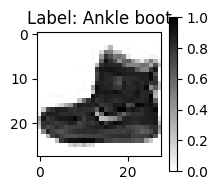

In [2]:
# Load the Fashion MNIST dataset
(train_images, train_labels), (test_images, test_labels) = keras.datasets.fashion_mnist.load_data()

# Normalize pixel values to be between 0 and 1
train_images = train_images / 255.0
test_images = test_images / 255.0

# Reshape images to a 1D vector for a Feed Forward Neural Network
# Each image is 28x28 pixels, so we flatten it to 784 features
train_images_flat = train_images.reshape(-1, 28 * 28)
test_images_flat = test_images.reshape(-1, 28 * 28)

# Define class names for plotting
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"Training images shape: {train_images_flat.shape}")
print(f"Training labels shape: {train_labels.shape}")
print(f"Test images shape: {test_images_flat.shape}")
print(f"Test labels shape: {test_labels.shape}")

# Display the first image from the training set
plt.figure(figsize=(2,2))
plt.imshow(train_images[0], cmap=plt.cm.binary)
plt.title(f"Label: {class_names[train_labels[0]]}")
plt.colorbar()
plt.grid(False)
plt.show()

### Step 2: Define the Feed Forward Neural Network Model

We'll build a simple FFNN using Keras's Sequential API. It will consist of an input layer, one or more hidden dense layers with ReLU activation, and an output dense layer with softmax activation for multi-class classification.

In [3]:
# Define the FFNN model architecture
model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(28 * 28,)), # Input layer and first hidden layer
    keras.layers.Dense(64, activation='relu'),                          # Second hidden layer
    keras.layers.Dense(10, activation='softmax')                         # Output layer for 10 classes
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

### Step 3: Compile the Model

Before training, we need to compile the model. We'll specify:
-   **Optimizer**: How the model updates its weights (e.g., `'adam'`).
-   **Loss Function**: How the model measures its error during training (e.g., `'sparse_categorical_crossentropy'` for integer labels).
-   **Metrics**: What to monitor during training and testing (e.g., `'accuracy'`).

In [4]:
# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

### Step 4: Train the Model

Now we'll train the model using our preprocessed training data. We'll specify the number of `epochs` (how many times the model sees the entire dataset) and a `validation_split` to monitor performance on a portion of the training data that is held out during training.

In [10]:
# Train the model
history = model.fit(train_images_flat, train_labels, epochs=10,validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9124 - loss: 0.2321 - val_accuracy: 0.8842 - val_loss: 0.3232
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9147 - loss: 0.2253 - val_accuracy: 0.8898 - val_loss: 0.3158
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9167 - loss: 0.2194 - val_accuracy: 0.8859 - val_loss: 0.3397
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9190 - loss: 0.2144 - val_accuracy: 0.8872 - val_loss: 0.3288
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9225 - loss: 0.2057 - val_accuracy: 0.8867 - val_loss: 0.3636
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9234 - loss: 0.2008 - val_accuracy: 0.8904 - val_loss: 0.3468
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9270 - loss: 0.1932 - val_accuracy: 0.8922 - val_loss: 0.3383
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9288 - loss: 0.1887 -

### Step 5: Evaluate the Model

Finally, we'll evaluate the trained model on the unseen test data to see how well it generalizes.

313/313 - 1s - 2ms/step - accuracy: 0.8769 - loss: 0.3532

Test accuracy: 0.8769000172615051


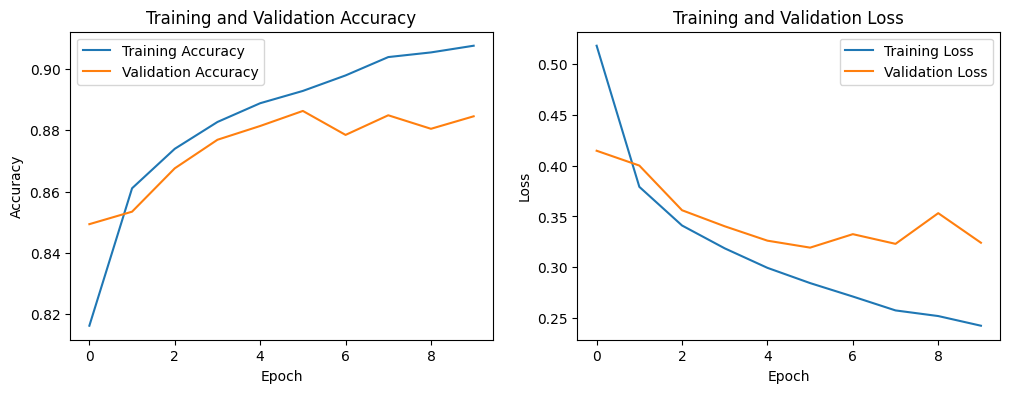

In [6]:
# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(test_images_flat, test_labels, verbose=2)

print(f"\nTest accuracy: {test_accuracy}")

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

### Visualize Predictions

Let's visualize some of the test images along with their predicted labels and true labels. This will give us a qualitative understanding of the model's performance.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


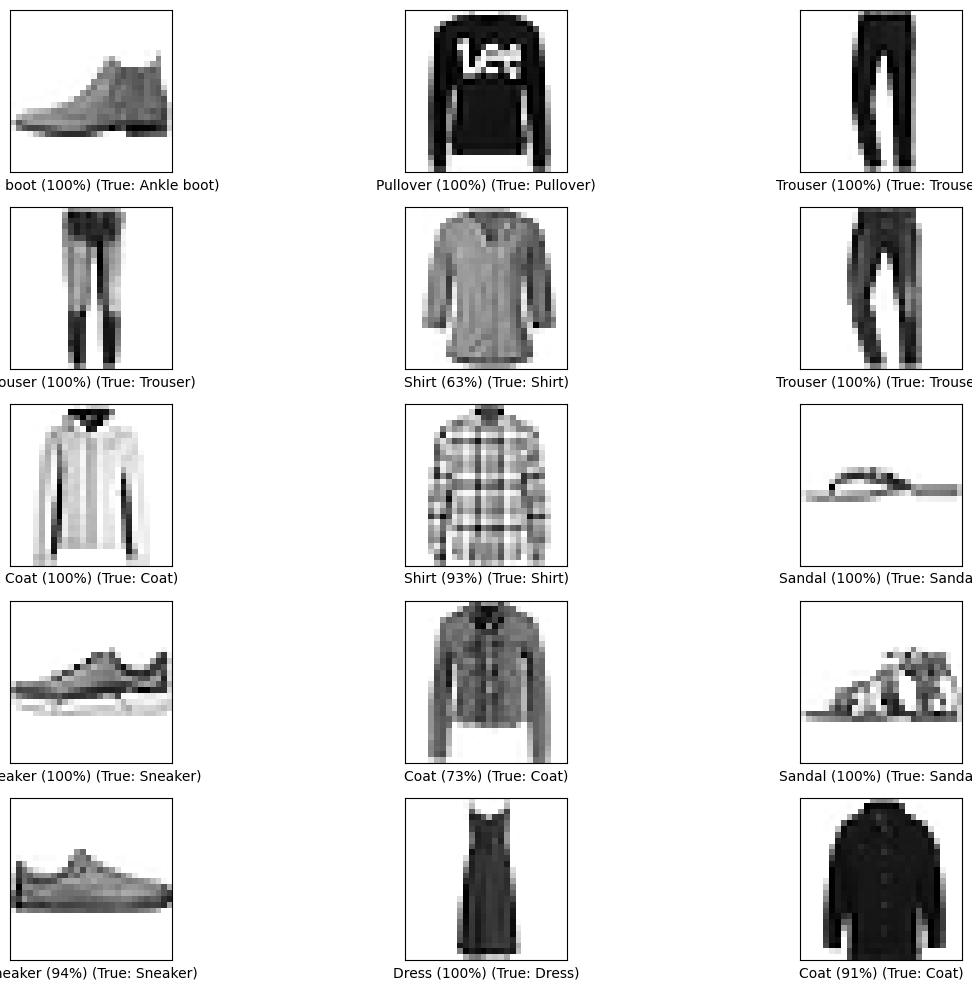

In [7]:
# Make predictions on the test dataset
predictions = model.predict(test_images_flat)

# Function to plot image, true label, and predicted label
def plot_image(i, predictions_array, true_label, img):
    true_label, img = true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img, cmap=plt.cm.binary)

    predicted_label = np.argmax(predictions_array)
    color = 'blue' if predicted_label == true_label else 'red'

    plt.xlabel(f"{class_names[predicted_label]} ({100*np.max(predictions_array):2.0f}%) (True: {class_names[true_label]})")
    plt.textColor = color

# Plot the first X test images, their predicted labels, and the true labels.
# Color correct predictions in blue and incorrect predictions in red.
num_rows = 5
num_cols = 3
num_images = num_rows * num_cols
plt.figure(figsize=(2 * 2 * num_cols, 2 * num_rows))
for i in range(num_images):
    plt.subplot(num_rows, 2 * num_cols, 2 * i + 1)
    plot_image(i, predictions[i], test_labels, test_images)
plt.tight_layout()
plt.show()